# CNN for AI-Generated Face Detection

**Objectives**

1. Train a ResNet classifier on real vs AI-generated faces2. 
Achieve competitive classification accuracy

## 1. Setup & Configuration

### Data Download and Folder Cleaning

In [1]:
from data_utils import download_and_create_data_folder
download_and_create_data_folder()

Dataset URL: https://www.kaggle.com/datasets/philosopher0808/real-vs-ai-generated-faces-dataset
License(s): MIT


100%|██████████| 7.19G/7.19G [1:13:04<00:00, 1.76MB/s]



Extracting dataset...
DONE
Data available at: /home/hassan.ray/cs7150_project/data


In [4]:
from data_utils import clean_source_folders
clean_source_folders()

Missing: /home/hassan.ray/cs7150_project/data/source/real/ffhq
Missing: /home/hassan.ray/cs7150_project/data/source/fake/GAN/sfhq
Missing: /home/hassan.ray/cs7150_project/data/source/fake/GAN/thispersondoesnotexist
Missing: /home/hassan.ray/cs7150_project/data/source/fake/Diffusion/stable_diffusion
Missing: /home/hassan.ray/cs7150_project/data/source/fake/FaceSwap/faceswap
DONE


### Imports and Device Configuration

In [1]:
import os
import copy
import random
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
from torchvision.transforms import Normalize
from torchvision import datasets, transforms, models
from torchvision.models import resnet18, vit_b_16
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
from resnet_helpers.resnet_model import load_resnet_model, train_model, evaluate

In [2]:
device = torch.device("cuda")
print("Using device:", device)

Using device: cuda


### Data Loading (Train, Test, Val) and Transformation (Augmentation)

In [3]:
data_dir = Path("data/dataset")  # dataset/train, dataset/test, dataset/validate
train_dir = data_dir / "train"
val_dir   = data_dir / "validate"
test_dir  = data_dir / "test"

In [4]:
img_size = 224
batch_size = 128


train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [5]:
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset   = datasets.ImageFolder(val_dir, transform=eval_transform)
test_dataset  = datasets.ImageFolder(test_dir, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2,pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2,pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2,pin_memory=True)

label_map = {
    0: "real",
    1: "fake"
}
class_to_idx = train_dataset.class_to_idx

print("Classes:", label_map)
print("Class to index:", class_to_idx)
print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

Classes: {0: 'real', 1: 'fake'}
Class to index: {'0': 0, '1': 1}
Train size: 72574
Validation size: 24190
Test size: 24190


### Visualize Dataset (After Augmentation)

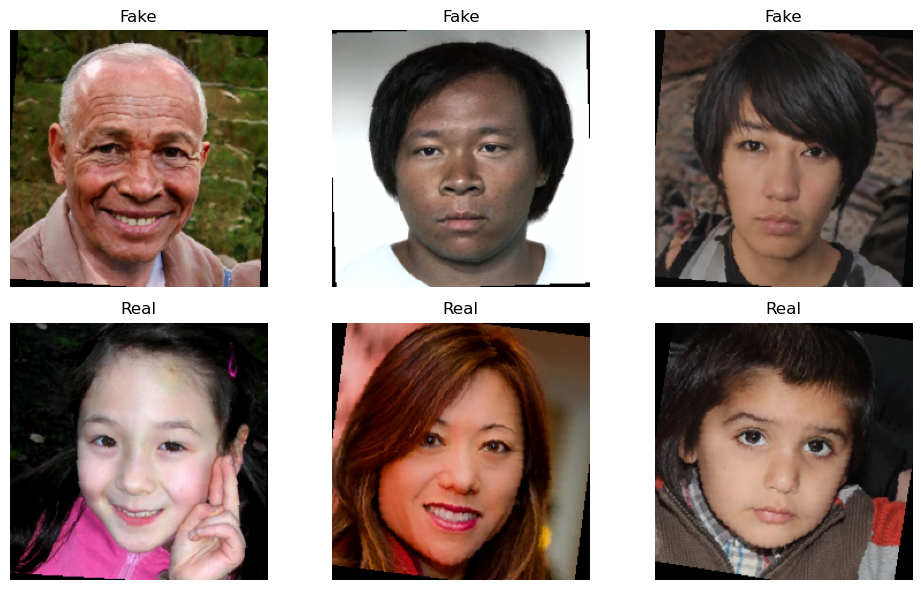

In [6]:
fake_imgs = []
real_imgs = []

for images, labels in train_loader:
    for img, label in zip(images, labels):
        if label.item() == 1 and len(fake_imgs) < 3:   # 1 = fake
            fake_imgs.append(img)
        elif label.item() == 0 and len(real_imgs) < 3: # 0 = real
            real_imgs.append(img)

        if len(fake_imgs) == 3 and len(real_imgs) == 3:
            break
    if len(fake_imgs) == 3 and len(real_imgs) == 3:
        break

# plot
plt.figure(figsize=(10, 6))

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

# fake row
for i in range(3):
    img = fake_imgs[i].numpy().transpose((1, 2, 0))
    img = std * img + mean
    img = np.clip(img, 0, 1)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title("Fake")
    plt.axis("off")

# real row
for i in range(3):
    img = real_imgs[i].numpy().transpose((1, 2, 0))
    img = std * img + mean
    img = np.clip(img, 0, 1)

    plt.subplot(2, 3, 3 + i + 1)
    plt.imshow(img)
    plt.title("Real")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 2. ResNet Architecture

In [7]:
from resnet_helpers.resnet_model import get_resnet_model, load_resnet_model

resnet_model = get_resnet_model().to(device)
print(resnet_model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## 4. Training

In [15]:
loss = nn.CrossEntropyLoss()
model_path = "resnet_model.pth"

if os.path.exists(model_path):
    print("Model found.")

    resnet_model = load_resnet_model(model_path, device)

else:
    print("No model found. Training...")

    resnet_optimizer = optim.AdamW(
        resnet_model.parameters(),
        lr=5e-5,
        weight_decay=1e-4
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(resnet_optimizer, T_max=20)

    resnet_model, resnet_history = train_model(
        resnet_model,
        train_loader,
        val_loader,
        loss,
        resnet_optimizer,
        device,
        epochs=20,
        scheduler=scheduler
    )

    torch.save(resnet_model.state_dict(), model_path)

No model found. Training...

Epoch 1/20
----------------------------------------
    Batch [100/567] - Loss: 0.4148 - Acc: 0.8068
    Batch [200/567] - Loss: 0.3401 - Acc: 0.8491
    Batch [300/567] - Loss: 0.2977 - Acc: 0.8716
    Batch [400/567] - Loss: 0.2694 - Acc: 0.8855
    Batch [500/567] - Loss: 0.2484 - Acc: 0.8961
    Batch [567/567] - Loss: 0.2373 - Acc: 0.9017
Train Loss: 0.2373 | Train Acc: 0.9017
Val   Loss: 0.1401 | Val   Acc: 0.9491
Epoch Time: 217.38 seconds

Epoch 2/20
----------------------------------------
    Batch [100/567] - Loss: 0.1255 - Acc: 0.9517
    Batch [200/567] - Loss: 0.1208 - Acc: 0.9548
    Batch [300/567] - Loss: 0.1213 - Acc: 0.9550
    Batch [400/567] - Loss: 0.1178 - Acc: 0.9560
    Batch [500/567] - Loss: 0.1149 - Acc: 0.9570
    Batch [567/567] - Loss: 0.1146 - Acc: 0.9570
Train Loss: 0.1146 | Train Acc: 0.9570
Val   Loss: 0.1091 | Val   Acc: 0.9587
Epoch Time: 185.87 seconds

Epoch 3/20
----------------------------------------
    Batch [100/

### Training Loss and Accuracy Visualization

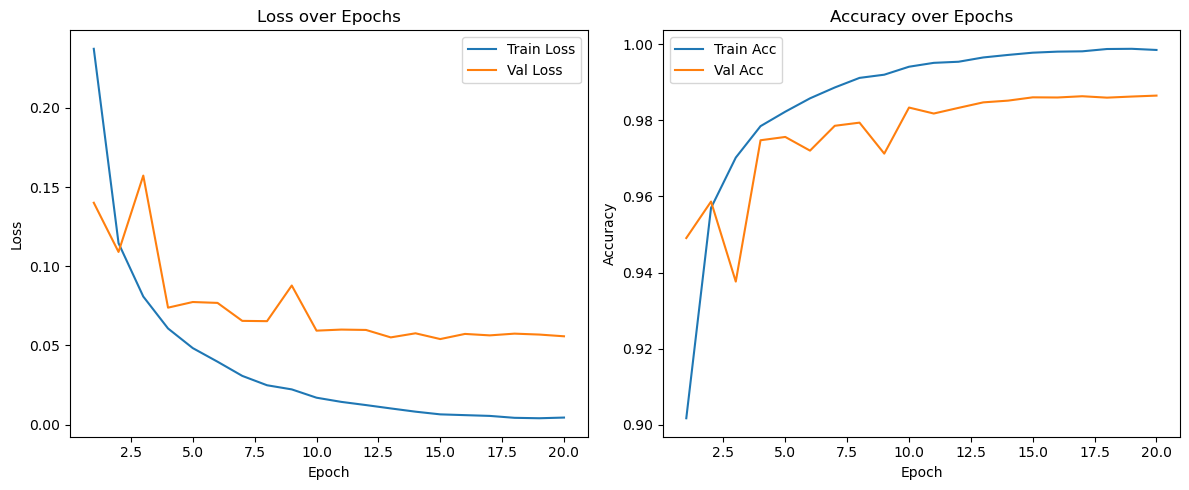

In [17]:
epochs = range(1, len(resnet_history["train_loss"]) + 1)

plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, resnet_history["train_loss"], label="Train Loss")
plt.plot(epochs, resnet_history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss over Epochs")
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, resnet_history["train_acc"], label="Train Acc")
plt.plot(epochs, resnet_history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy over Epochs")
plt.legend()

plt.tight_layout()
plt.savefig("resnet_model_outputs/loss_accuracy.png", dpi=300)
plt.show()